# Phase 6 — Train (split + Generator A + IF baseline + LSTM-AE bake-off)

> Issue #27 · design: `backend/docs/designs/27-task-phase6-train.md` · gate: `backend/docs/ml/07-train.md`

**This is where the test-set firewall becomes real.** The split is DEFINED and the TEST fold
(2020) is SEALED — never loaded or scored here. `test_set.burned` stays `false` until Phase 7.

What this notebook RUNS (logic is in the tested `backend/core/*` modules; this orchestrates):
1. `build_features` → `split_by_monday` → `assert_firewall` (3 CRITICAL guards)
2. fit-on-TRAIN-only: `StandardScaler` + `T = P95(train len)`; `to_sequences`
3. Generator A: §6-calibrated synthetic injections on VAL (`make_eval_set`)
4. IsolationForest baseline (run FIRST — guardrail #10)
5. LSTM-AE: train on TRAIN-normal; train/val loss curves; scoring aggregation
6. Bake-off (D-005 metrics, D-006 rule) → confirm `model_track`; threshold-on-VAL + FPR guardrail
7. `dist_to_runway_m` ablation; seen-vs-unseen-`icao24` AUROC delta (eng-review-2)

FIREWALL: inject on VAL only; scaler+T fit on TRAIN only; TEST never touched.

> ## ⚠️ STATUS BANNER — read before trusting the conclusions below
>
> Cells were **re-executed after a codex review** fixed two P2 bugs (injection-onset clamp + LSTM
> encoder ignoring padding — see `07-train.md` "Codex review"), so the embedded numbers are
> **current** (best AE = `small/mean`, val AUROC **0.664**, post-fix).
>
> **The "ship AE / `model_track`=dl confirmed" line in §6 is PROVISIONAL.** The bake-off here only
> compares the AE to IsolationForest. A **wider baseline panel** (`notebooks/12_density_baselines`)
> shows a simple **kNN-on-summary scores 0.707 > the AE's 0.664** on this same val firewall — the
> deep model doesn't earn its complexity on synthetic. Model choice is **deferred to the Phase-7
> real-anomaly test**, AE + a frozen kNN carried in blind (`07-eval-prep.md` Layer 6).
>
> Read the **per-type** result (not the mean): the AE's value is the **dynamic** anomalies
> (loiter 0.95, intercept 0.79); `zone`/`altitude` are near-chance and out of the AE's remit
> (APW's job, per the D-010 reframe).
>
> **Companions:** `10_sadar_comparison` (benchmark-difficulty vs SADAR), `11_phase6_loopback`
> (4 levers — none beat baseline), `12_density_baselines` (wider panel — kNN > AE).
> Full write-up + decisions: `backend/docs/ml/07-train.md`.

In [1]:
import sys, glob, json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, fbeta_score

REPO = Path.cwd()
while not (REPO / "backend/core/preprocessing.py").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from backend.core.features import build_features
from backend.core import split as sp
from backend.core.preprocessing import (
    AE_FEATURES, SCALER_FEATURES, make_scaler, to_sequences, to_sequences_loss_mask)
from backend.core.inject import make_eval_set, DEFAULT_MIX
from backend.core.baseline import IsolationForestBaseline
from backend.core import lstm_ae as ae

SEED = 42
DATA = REPO / "data/raw/opensky_states"
FIG = REPO / "backend/docs/ml/figures"; FIG.mkdir(parents=True, exist_ok=True)
MODELS = REPO / "backend/models/phase6"; MODELS.mkdir(parents=True, exist_ok=True)
print("AE_FEATURES:", AE_FEATURES)

AE_FEATURES: ['lat', 'lon', 'baroaltitude', 'velocity', 'vertrate', 'dist_to_runway_m', 'hdg_sin', 'hdg_cos', 'onground']


## 1. Load + preprocess → split + firewall

`build_features` is the Phase-3/5 pipeline (unfitted). It takes ~2 min on the 18 Mondays, so
we cache `clean_df`/`meta`. The split is temporal-by-Monday (train 2017-18 < val 2019 < test
2020); held-aside (`emergency ∪ go_around ∪ impossible`) is pulled pre-split.

In [2]:
cache_c, cache_m = MODELS / "clean_df.parquet", MODELS / "meta.parquet"
if cache_c.exists() and cache_m.exists():
    clean_df, meta = pd.read_parquet(cache_c), pd.read_parquet(cache_m)
else:
    files = sorted(glob.glob(str(DATA / "lemd_*__opensky_states_*.parquet")))
    raw = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    t = time.time(); clean_df, meta = build_features(raw)
    clean_df.to_parquet(cache_c); meta.to_parquet(cache_m)
    print(f"build_features {time.time()-t:.0f}s")
print(f"{len(clean_df):,} rows, {meta['segment_id'].nunique():,} segments")

3,155,859 rows, 19,849 segments


In [3]:
split = sp.split_by_monday(meta)
sp.assert_firewall(split)          # 3 CRITICAL guards: no-test-leak / no-identity-leak / temporal
print("clean fold counts :", split.counts)
print("block counts      :", split.block_counts, "→ sum", sum(split.block_counts.values()))
assert split.block_counts == {"train": 9338, "val": 6073, "test": 4438}, "locked-table mismatch"
print("icao24 overlap    :", split.icao24_overlap, "(reported, not asserted — eng-review-2)")

clean fold counts : {'train': 8924, 'val': 5942, 'test': 4285, 'held_aside': 698}
block counts      : {'train': 9338, 'val': 6073, 'test': 4438} → sum 19849
icao24 overlap    : {'train_val': 555, 'train_test': 406, 'val_test': 398, 'all_three': 274} (reported, not asserted — eng-review-2)


## 2. Fit on TRAIN only — scaler + sequence length T

The fit/transform firewall (guardrail #5): the `StandardScaler` and `T` are computed on TRAIN
and applied unchanged to val/test. `T = P95(train segment length)`; longer tails are truncated
(`was_truncated`) rather than letting one long hold blow up the tensor.

In [4]:
train_df = sp.subset(clean_df, split.train_ids)
val_df   = sp.subset(clean_df, split.val_ids)

T = int(np.percentile(train_df.groupby("segment_id").size(), 95))
scaler = make_scaler().fit(train_df[SCALER_FEATURES])   # TRAIN only
X_train, _, info_train = to_sequences(train_df, T, scaler)
mask_train = to_sequences_loss_mask(train_df, T)
X_valn, _, _ = to_sequences(val_df, T, scaler)          # normal val (for the loss curve)
mask_valn = to_sequences_loss_mask(val_df, T)
print(f"T={T}  X_train={X_train.shape}  truncated={int(info_train['was_truncated'].sum())}")

T=260  X_train=(8924, 260, 9)  truncated=439


## 3. Generator A — §6-calibrated synthetic injections on VAL

There are no real anomaly labels in cycle 3 (D-008 OQ#1), so model selection scores against
INJECTED anomalies. `make_eval_set` keeps half of VAL normal (label 0) and perturbs the rest
with the §6 mix (label 1), windowing+scaling both with the TRAIN scaler. Inject VAL/TEST only.
**Freeze this bench after Phase 6** (seed + §6 params + scaler + T) so Phase 7 is identical.

In [5]:
val_set = make_eval_set(clean_df, split.val_ids, scaler, T, seed=SEED, fold="val", inject_rate=0.5)
print(f"val eval set: {len(val_set.y)} windows, {int(val_set.y.sum())} anomalies")
print("§6 mix:", DEFAULT_MIX)
print("realized:", pd.Series([k for k in val_set.kind if k != 'normal']).value_counts(normalize=True).round(3).to_dict())

val eval set: 5942 windows, 2971 anomalies
§6 mix: {'zone_violation': 0.4, 'altitude_high': 0.2, 'sustained_loiter': 0.2, 'final_approach_intercept': 0.1, 'speed_spike': 0.1}
realized: {'zone_violation': 0.413, 'sustained_loiter': 0.203, 'altitude_high': 0.201, 'final_approach_intercept': 0.097, 'speed_spike': 0.087}


## 4. IsolationForest baseline (run FIRST — guardrail #10)

In [6]:
base = IsolationForestBaseline.fit(X_train, mask_train, seed=SEED)
if_score = base.anomaly_score(val_set.X, val_set.loss_mask)
if_auroc = roc_auc_score(val_set.y, if_score)
print(f"IF val AUROC = {if_auroc:.4f}")

IF val AUROC = 0.6246


## 5. LSTM-AE — train on TRAIN-normal; loss curves; scoring aggregation

Capped val iteration (eng-review-2, decision D4): two capacities × three scoring aggregations.
Injected anomalies are localized post-onset, so a **max/top-k** over timesteps concentrates the
signal a mean would dilute. Test stays sealed throughout.

In [7]:
CONFIGS = {"small": dict(hidden=32, latent=16, num_layers=1),
           "big":   dict(hidden=64, latent=32, num_layers=2)}
AGGS = ["mean", "max", "topk"]
grid, models, hists = {}, {}, {}
for name, cfg in CONFIGS.items():
    m, h = ae.train_autoencoder(X_train, mask_train, X_valn, mask_valn,
                                lr=1e-3, max_epochs=60, patience=8, batch_size=128, seed=SEED, **cfg)
    models[name], hists[name] = m, h
    for agg in AGGS:
        grid[f"{name}/{agg}"] = roc_auc_score(
            val_set.y, ae.reconstruction_error(m, val_set.X, val_set.loss_mask, agg=agg))
pd.Series(grid).sort_values(ascending=False).round(4)

small/mean    0.6642
small/topk    0.6615
big/topk      0.6590
big/mean      0.6572
small/max     0.6486
big/max       0.6455
dtype: float64

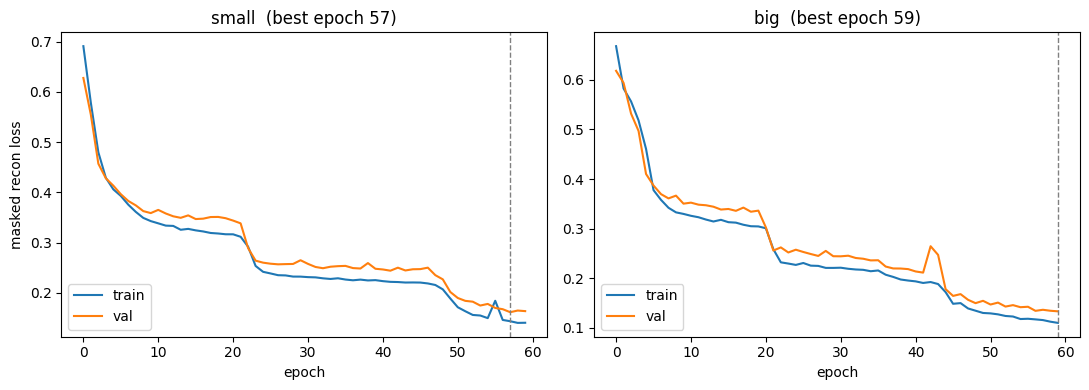

In [8]:
# train/val loss curves (guardrail #7 — over/underfit visible)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, CONFIGS):
    h = hists[name]
    ax.plot(h.train_loss, label="train"); ax.plot(h.val_loss, label="val")
    ax.axvline(h.best_epoch, ls="--", c="gray", lw=1)
    ax.set_title(f"{name}  (best epoch {h.best_epoch})"); ax.set_xlabel("epoch"); ax.legend()
axes[0].set_ylabel("masked recon loss"); plt.tight_layout()
plt.savefig(FIG / "phase6_loss_curves.png", dpi=110); plt.show()

## 6. Bake-off — D-006 selection, threshold-on-VAL, FPR guardrail

D-006: ship the AE iff `AE_AUROC ≥ IF_AUROC + 0.03`, else ship IF. Then pick the threshold on
the injected-VAL curve (highest F2 subject to **FPR ≤ 15%**, D-005). Selection orders the
models; the guardrail is a veto. Bootstrap 95% CI on AUROC.

In [9]:
best_key = max(grid, key=grid.get)
best_name, best_agg = best_key.split("/")
best_model, best_hist = models[best_name], hists[best_name]
ae_auroc = grid[best_key]
ae_score = ae.reconstruction_error(best_model, val_set.X, val_set.loss_mask, agg=best_agg)

ship_ae = ae_auroc >= if_auroc + 0.03
winner, win_score = ("AE", ae_score) if ship_ae else ("IF", if_score)
print(f"best AE config = {best_key}  AUROC {ae_auroc:.4f}")
print(f"D-006: AE {ae_auroc:.4f}  vs  IF+0.03 {if_auroc+0.03:.4f}  →  ship {winner}")

best AE config = small/mean  AUROC 0.6642
D-006: AE 0.6642  vs  IF+0.03 0.6546  →  ship AE


In [10]:
def pick_threshold(y, score, max_fpr=0.15):
    best_thr, best_f2 = None, -1.0
    for thr in np.unique(score):
        pred = (score >= thr).astype(int)
        tn = ((pred==0)&(y==0)).sum(); fp = ((pred==1)&(y==0)).sum()
        if fp/max(fp+tn,1) <= max_fpr:
            f2 = fbeta_score(y, pred, beta=2, zero_division=0)
            if f2 > best_f2: best_f2, best_thr = f2, thr
    return best_thr

def boot_ci(y, score, n=1000, seed=SEED):
    r = np.random.default_rng(seed); a=[]
    for _ in range(n):
        idx = r.integers(0, len(y), len(y))
        if len(np.unique(y[idx]))==2: a.append(roc_auc_score(y[idx], score[idx]))
    return float(np.percentile(a,2.5)), float(np.percentile(a,97.5))

thr = pick_threshold(val_set.y, win_score)
pred = (win_score >= thr).astype(int)
tn = int(((pred==0)&(val_set.y==0)).sum()); fp = int(((pred==1)&(val_set.y==0)).sum())
fpr = fp/max(fp+tn,1); f2 = fbeta_score(val_set.y, pred, beta=2, zero_division=0)
pr_auc = average_precision_score(val_set.y, win_score)
ae_lo, ae_hi = boot_ci(val_set.y, ae_score); if_lo, if_hi = boot_ci(val_set.y, if_score)
print(f"IF AUROC {if_auroc:.4f} [{if_lo:.3f},{if_hi:.3f}]")
print(f"AE AUROC {ae_auroc:.4f} [{ae_lo:.3f},{ae_hi:.3f}]  (agg={best_agg})")
print(f"[{winner}] thr={thr:.4f}  F2={f2:.3f}  FPR={fpr:.3f}  PR-AUC={pr_auc:.3f}  guardrail_ok={fpr<=0.15}")

IF AUROC 0.6246 [0.611,0.639]
AE AUROC 0.6642 [0.651,0.678]  (agg=mean)
[AE] thr=0.2217  F2=0.451  FPR=0.149  PR-AUC=0.698  guardrail_ok=True


## 7. `dist_to_runway_m` ablation (Phase-5 deferred empirical test)

Does the Phase-5-promoted feature improve val AUROC? Zero its scaled channel (≈ train mean,
neutral), retrain the winning config, compare. A non-positive Δ means the promotion didn't earn
its place empirically — a writeup finding.

In [11]:
di = AE_FEATURES.index("dist_to_runway_m")
Xtr_a = X_train.copy(); Xtr_a[:,:,di]=0; Xvn_a = X_valn.copy(); Xvn_a[:,:,di]=0
Xve_a = val_set.X.copy(); Xve_a[:,:,di]=0
m_abl, _ = ae.train_autoencoder(Xtr_a, mask_train, Xvn_a, mask_valn,
                                lr=1e-3, max_epochs=60, patience=8, batch_size=128,
                                seed=SEED, **CONFIGS[best_name])
ae_auroc_abl = roc_auc_score(val_set.y, ae.reconstruction_error(m_abl, Xve_a, val_set.loss_mask, agg=best_agg))
print(f"AE with dist    : {ae_auroc:.4f}")
print(f"AE without dist : {ae_auroc_abl:.4f}   Δ = {ae_auroc-ae_auroc_abl:+.4f}")

AE with dist    : 0.6642
AE without dist : 0.6614   Δ = +0.0027


## 8. Seen-vs-unseen-`icao24` AUROC delta (eng-review-2 / Codex)

`icao24` overlaps train↔val by design (airframes recur at LEMD). "No identity feature" kills
*direct* leakage, but the AE could learn an airframe's kinematic template from the features.
We MEASURE that optimism: AUROC on VAL segments whose airframe was seen in TRAIN vs not. A large
positive delta (seen ≫ unseen) would mean recurrence inflates the score; a small/negative delta
supports the harmlessness claim.

In [12]:
train_ac = set(meta[meta["segment_id"].isin(set(split.train_ids))]["icao24"])
seg_ac = meta.groupby("segment_id")["icao24"].first()
seen = np.array([seg_ac.get(s) in train_ac for s in val_set.segment_id])
def ga(sel):
    y, s = val_set.y[sel], win_score[sel]
    return roc_auc_score(y, s) if len(np.unique(y))==2 else float("nan")
print(f"seen   icao24 AUROC {ga(seen):.4f}  (n={int(seen.sum())})")
print(f"unseen icao24 AUROC {ga(~seen):.4f}  (n={int((~seen).sum())})")
print(f"Δ (seen − unseen) = {ga(seen)-ga(~seen):+.4f}   (≈0 or <0 → overlap benign)")

seen   icao24 AUROC 0.6463  (n=4387)
unseen icao24 AUROC 0.7125  (n=1555)
Δ (seen − unseen) = -0.0662   (≈0 or <0 → overlap benign)


## 9. Reconstruction overlay — a normal vs an injected window (winning model)

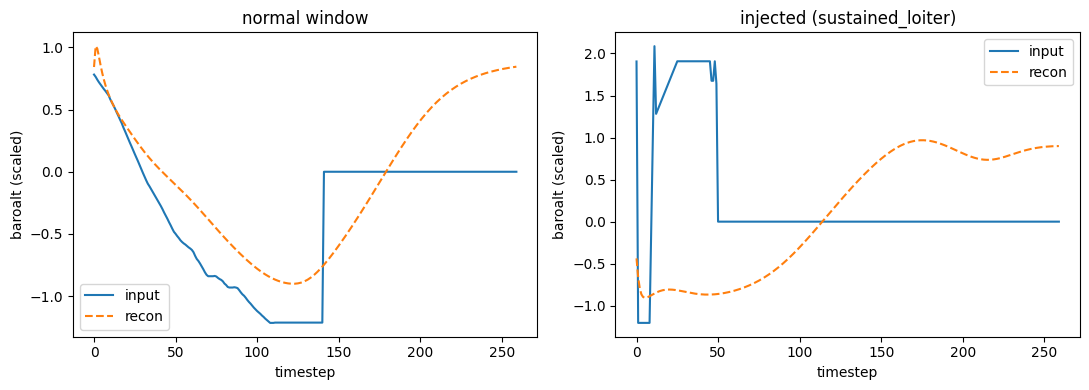

In [13]:
import torch
def overlay(ax, X, i, title):
    x = X[i]
    with torch.no_grad():
        r = best_model(torch.from_numpy(x[None]).float())[0].numpy()
    f = AE_FEATURES.index("baroaltitude")
    ax.plot(x[:, f], label="input"); ax.plot(r[:, f], label="recon", ls="--")
    ax.set_title(title); ax.legend(); ax.set_xlabel("timestep"); ax.set_ylabel("baroalt (scaled)")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ni = int(np.where(val_set.y==0)[0][0]); ai = int(np.where(val_set.y==1)[0][0])
overlay(axes[0], val_set.X, ni, "normal window")
overlay(axes[1], val_set.X, ai, f"injected ({val_set.kind[ai]})")
plt.tight_layout(); plt.savefig(FIG / "phase6_recon_overlay.png", dpi=110); plt.show()

## 10. Save artifacts + the manifest `test_set` block

Persist the winning model + the split (test ids stay a sealed reference, not scored). The
`manifest.test_set` block is emitted for the gate write-up; `burned` stays `false`.

In [14]:
ae.save_checkpoint(best_model, str(MODELS / "lstm_ae_best.pt"),
                   val_score=float(ae_auroc), threshold=float(thr),
                   extra={"config": best_name, "agg": best_agg, "T": int(T), "seed": SEED})
json.dump(
    {"train": split.train_ids, "val": split.val_ids, "test": split.test_ids,
     "held_aside": split.held_aside_ids},
    open(MODELS / "split_ids.json", "w"))
print(json.dumps(split.manifest_test_set(holdout_path="backend/models/phase6/split_ids.json"), indent=2))
print("\nFIREWALL: test fold defined + sealed; burned stays FALSE until Phase 7.")

{
  "defined_at": null,
  "split_seed": null,
  "split_strategy": "temporal-by-Monday (train 2017-18 < val 2019 < test 2020) + no-identity-leak guard (icao24/flight_id \u2209 AE_FEATURES); held-aside emergency\u222ago_around\u222aimpossible pulled pre-split (D-009 + eng-review-2)",
  "holdout_path": "backend/models/phase6/split_ids.json",
  "count": 4285,
  "burned": false,
  "burned_at": null,
  "burn_reason": null
}

FIREWALL: test fold defined + sealed; burned stays FALSE until Phase 7.


## Summary (Phase 6 — closed; gate written)

- **Split + firewall:** 19,849 segments → train 8,924 / val 5,942 / **test 4,285 (SEALED)** /
  held-aside 698; block counts match the locked table; `burned: false`.
- **Bake-off (post-codex-fix):** IF 0.625 → **LSTM-AE `small/mean` 0.664 [0.651, 0.678]**;
  threshold 0.222, F2 0.451, FPR 0.149 (guardrail holds), PR-AUC 0.698.
- **`dist` ablation** Δ +0.003 (neutral); **seen/unseen-`icao24`** Δ −0.066 (recurrence benign).
- **Provisional model choice:** AE beats IF, but a **wider panel (nb12) shows kNN 0.707 > AE** →
  `track_confirmed: false`; AE + frozen kNN carried, blind, into the **Phase-7 real-anomaly test**
  (the decider), pre-registered in `07-eval-prep.md` Layer 6.
- **Read the per-type table, not the 0.66 mean:** the AE owns the *dynamic* anomalies
  (loiter 0.95, intercept 0.79); `zone`/`altitude` are near-chance and out of remit (APW's job).

Gate recorded in `backend/docs/ml/07-train.md` + `manifest.yml > gates.train` (passed, with the
provisional-model concern). **The TEST fold was never scored here.** Companions: nb10 (SADAR),
nb11 (loop-back), nb12 (density panel).